# Hurricane Track Generation with LSTM-VAE

This notebook now uses an object-oriented structure for hurricane data and generation:

- `Hurricane`: Base class for hurricane tracks (common attributes, plotting, summary).
- `HistoricHurricane`: For real hurricanes parsed from HURDAT2.
- `SyntheticHurricane`: For synthetic hurricanes generated by LSTM-VAE.
- `HurricaneLSTMVAE`: Model class for LSTM-VAE.

This structure improves modularity, clarity, and extensibility.

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.saving import register_keras_serializable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pickle
import re
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check TensorFlow version
print(f"TensorFlow version: {tf.__version__}")

# Enable memory growth on GPUs if available
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPU(s), memory growth enabled")
    except RuntimeError as e:
        print(f"GPU setup error: {e}")
else:
    print("No GPUs found, running on CPU")

TensorFlow version: 2.19.0
No GPUs found, running on CPU


## Object-Oriented Hurricane Classes

We define a base `Hurricane` class, and two subclasses: `HistoricHurricane` and `SyntheticHurricane`.

In [8]:
# filepath: /Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Hurricane/Hurricane-LSTM-VAE V1.ipynb
class Hurricane:
    def __init__(self, track_df):
        self.track_df = track_df

    def plot(self, title="Hurricane Track"):
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())
        try:
            osm_tiles = cimgt.OSM()
            ax.add_image(osm_tiles, 8)
        except Exception:
            pass
        plt.plot(self.track_df['longitude'], self.track_df['latitude'],
                 '-o', markersize=4, label=getattr(self, 'storm_name', 'Track'), transform=ccrs.PlateCarree())
        scatter = plt.scatter(self.track_df['longitude'], self.track_df['latitude'],
                              c=self.track_df['max_wind'], cmap='YlOrRd', transform=ccrs.PlateCarree())
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')
        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()

    def summary(self):
        print(self.track_df.describe())

class HistoricHurricane(Hurricane):
    @classmethod
    def from_hurdat2(cls, hurdat2_file, storm_id):
        handler = HurricaneDataHandler(hurdat2_file)
        df = handler.select_hurricane(storm_id)
        obj = cls(df)
        obj.storm_name = df['storm_name'].iloc[0] if not df.empty else storm_id
        return obj

    @staticmethod
    def get_training_sequences(hurdat2_file, **kwargs):
        handler = HurricaneDataHandler(hurdat2_file)
        return handler.prepare_training_data(**kwargs)

class SyntheticHurricane(Hurricane):
    def __init__(self, input_dim=17, latent_dim=32, sequence_length=None, lstm_units=64):
        # Initialize with an empty DataFrame for track_df
        super().__init__(pd.DataFrame())
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.scaler = MinMaxScaler()
        self.model = None
        self.trained = False

    def _build_model(self):
        # Internal method to build the LSTM-VAE model
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name="encoder_input")
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="encoder_lstm_1")(encoder_inputs)
        x = layers.LSTM(self.lstm_units, name="encoder_lstm_2")(x)
        self.z_mean = layers.Dense(self.latent_dim, name="z_mean")(x)
        self.z_log_var = layers.Dense(self.latent_dim, name="z_log_var")(x)
        z = layers.Lambda(_sampling, name="z_sampling")([self.z_mean, self.z_log_var])
        _ = VAELossLayer()([self.z_mean, self.z_log_var])
        self.encoder = keras.Model(encoder_inputs, [self.z_mean, self.z_log_var, z], name="encoder")
        latent_inputs = keras.Input(shape=(self.latent_dim,), name="decoder_latent_input")
        x = layers.RepeatVector(self.sequence_length, name="repeat_vector")(latent_inputs)
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="decoder_lstm_1")(x)
        x = layers.LSTM(self.lstm_units, return_sequences=True, name="decoder_lstm_2")(x)
        decoder_outputs = layers.TimeDistributed(layers.Dense(self.input_dim), name="decoder_output_timedistributed")(x)
        self.decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
        outputs = self.decoder(z)
        self.vae = keras.Model(encoder_inputs, outputs, name="lstm_vae")
        self.vae.compile(optimizer='adam', loss=self._reconstruction_loss_fn)

    def _reconstruction_loss_fn(self, y_true, y_pred):
        mse = tf.keras.losses.MeanSquaredError()
        return mse(y_true, y_pred)

    def preprocess_data(self, hurricane_sequences):
        if self.sequence_length is None:
            self.sequence_length = max([len(seq) for seq in hurricane_sequences])
        padded_sequences = []
        for seq in hurricane_sequences:
            if len(seq) > self.sequence_length:
                padded_sequences.append(seq[:self.sequence_length])
            elif len(seq) < self.sequence_length:
                padding = np.zeros((self.sequence_length - len(seq), self.input_dim))
                padded_sequences.append(np.vstack([seq, padding]))
            else:
                padded_sequences.append(seq)
        padded_sequences = np.array(padded_sequences, dtype=np.float32)
        original_shape = padded_sequences.shape
        flattened = padded_sequences.reshape(-1, self.input_dim)
        scaled_flattened = self.scaler.fit_transform(flattened)
        scaled_sequences = scaled_flattened.reshape(original_shape)
        return scaled_sequences

    def train(self, hurricane_sequences, epochs=50, batch_size=32, validation_split=0.2):
        if self.model is None:
            self._build_model()
        processed_sequences = self.preprocess_data(hurricane_sequences)
        history = self.vae.fit(
            processed_sequences, processed_sequences,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=validation_split,
            callbacks=[
                keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=10,
                    restore_best_weights=True
                )
            ]
        )
        self.trained = True
        return history

    def save(self, filepath):
        self.encoder.save(filepath + "_encoder.keras")
        self.decoder.save(filepath + "_decoder.keras")
        with open(filepath + "_scaler.pkl", 'wb') as f:
            pickle.dump(self.scaler, f)
        params = {
            'input_dim': self.input_dim,
            'latent_dim': self.latent_dim,
            'sequence_length': self.sequence_length,
            'lstm_units': self.lstm_units
        }
        with open(filepath + "_params.pkl", 'wb') as f:
            pickle.dump(params, f)

    def load(self, filepath):
        with open(filepath + "_params.pkl", 'rb') as f:
            params = pickle.load(f)
        self.input_dim = params['input_dim']
        self.latent_dim = params['latent_dim']
        self.sequence_length = params['sequence_length']
        self.lstm_units = params['lstm_units']
        with open(filepath + "_scaler.pkl", 'rb') as f:
            self.scaler = pickle.load(f)
        self._build_model()
        self.encoder = keras.models.load_model(filepath + "_encoder.keras", custom_objects={'_sampling': _sampling})
        self.decoder = keras.models.load_model(filepath + "_decoder.keras")
        encoder_inputs = keras.Input(shape=(self.sequence_length, self.input_dim), name="vae_input_loaded")
        z_mean, z_log_var, z = self.encoder(encoder_inputs)
        _ = VAELossLayer()([z_mean, z_log_var])
        reconstructed_outputs = self.decoder(z)
        self.vae = keras.Model(encoder_inputs, reconstructed_outputs, name="lstm_vae_loaded")
        self.vae.compile(optimizer='adam', loss=self._reconstruction_loss_fn)
        self.trained = True

    def generate(self, num_points=None, seed_features=None, randomness=0.5):
        if not self.trained:
            raise RuntimeError("Model must be trained or loaded before generating hurricanes.")
        if num_points is None:
            num_points = self.sequence_length
        if seed_features is not None:
            seed_data_scaled = self.preprocess_data([seed_features])
            z_mean, z_log_var, _ = self.encoder.predict(seed_data_scaled)
            epsilon = np.random.normal(0, 1, size=z_mean.shape)
            latent_vector = z_mean + np.exp(0.5 * z_log_var) * epsilon * randomness
        else:
            latent_vector = np.random.normal(0, 1, size=(1, self.latent_dim))
        generated_track_scaled = self.decoder.predict(latent_vector)[0]
        generated_track = self.scaler.inverse_transform(generated_track_scaled)
        if num_points and num_points < len(generated_track):
            generated_track = generated_track[:num_points]
        columns = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        track_df = pd.DataFrame(generated_track, columns=columns[:self.input_dim])
        start_date = datetime.now()
        track_df['datetime'] = [start_date + timedelta(hours=i*6) for i in range(len(track_df))]
        track_df['year'] = track_df['datetime'].dt.year
        track_df['month'] = track_df['datetime'].dt.month
        track_df['day'] = track_df['datetime'].dt.day
        track_df['hour'] = track_df['datetime'].dt.hour
        track_df['minute'] = 0
        track_df['status'] = 'HU'
        track_df['full_id'] = 'LSTM_SYN_' + start_date.strftime('%Y%m%d%H%M')
        track_df['storm_name'] = 'LSTM_Synthetic_' + start_date.strftime('%Y%m%d%H%M')
        if 'max_wind' in track_df.columns:
            track_df['max_wind'] = track_df['max_wind'].round().astype(int)
            track_df['max_wind'] = np.clip(track_df['max_wind'], 20, 180)
        if 'min_pressure' in track_df.columns:
            track_df['min_pressure'] = track_df['min_pressure'].round().astype(int)
            track_df['min_pressure'] = np.clip(track_df['min_pressure'], 880, 1020)
        for col in [
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]:
            if col in track_df.columns:
                track_df[col] = track_df[col].round().astype(int)
                track_df[col] = np.clip(track_df[col], 0, 400)
        track_df = self.apply_geographic_constraints(track_df)
        self.track_df = track_df
        self.storm_name = track_df['storm_name'].iloc[0]
        return self.track_df

    def apply_geographic_constraints(self, track_df, max_latitude=47):
        df = track_df.copy()
        for i in range(1, len(df)):
            lat_diff = abs(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude'])
            lon_diff = abs(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude'])
            if lat_diff > 3 or lon_diff > 3:
                df.loc[i, 'latitude'] = df.loc[i-1, 'latitude'] + np.sign(df.loc[i, 'latitude'] - df.loc[i-1, 'latitude']) * 1.5
                df.loc[i, 'longitude'] = df.loc[i-1, 'longitude'] + np.sign(df.loc[i, 'longitude'] - df.loc[i-1, 'longitude']) * 1.5
        for i in range(len(df)):
            if df.loc[i, 'latitude'] > 30:
                weakening_factor = max(0.3, 1.0 - (df.loc[i, 'latitude'] - 30) / 25)
                df.loc[i, 'max_wind'] = int(df.loc[i, 'max_wind'] * weakening_factor)
                df.loc[i, 'min_pressure'] = min(1020, int(df.loc[i, 'min_pressure'] + (1 - weakening_factor) * 50))
            if df.loc[i, 'latitude'] > max_latitude:
                df.loc[i, 'status'] = 'EX'
        df['longitude'] = ((df['longitude'] + 180) % 360) - 180
        return df

    def plot(self, title=None):
        if self.track_df is None or self.track_df.empty:
            print("No synthetic hurricane track to plot.")
            return
        super().plot(title or f"Synthetic Hurricane: {getattr(self, 'storm_name', '')}")

In [9]:
# Hurricane data parsing class - slightly modified from previous implementation
class HurricaneDataHandler:
    def __init__(self, hurdat2_file):
        self.hurdat2_file = hurdat2_file
        self.hurdat_df = self.parse_hurdat2()
        
    def parse_hurdat2(self):
        """Parse the HURDAT2 format file into a pandas DataFrame"""
        with open(self.hurdat2_file, 'r') as f:
            file_content = f.read()
        
        lines = file_content.strip().split('\n')
        data = []
        current_header = None
        
        for line in lines:
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = line.split(',')
                basin_id = parts[0].strip()
                basin = basin_id[:2]
                cyclone_number = basin_id[2:4]
                year = basin_id[4:8]
                name = parts[1].strip()
                num_entries = int(parts[2].strip())
                current_header = {
                    'basin': basin,
                    'cyclone_number': cyclone_number,
                    'year': year,
                    'full_id': basin_id,
                    'name': name,
                    'num_entries': num_entries
                }
            else:
                if current_header:
                    parts = line.split(',')
                    date_str = parts[0].strip()
                    time_str = parts[1].strip()
                    year = int(date_str[0:4])
                    month = int(date_str[4:6])
                    day = int(date_str[6:8])
                    hour = int(time_str[0:2]) if time_str else 0
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                    record_id = parts[2].strip()
                    status = parts[3].strip()
                    lat_str = parts[4].strip()
                    lon_str = parts[5].strip()
                    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                    max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                    min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                    
                    # Parse wind radii if available (34kt, 50kt, 64kt)
                    ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                    se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                    sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                    nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                    ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                    se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                    sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                    nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                    ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                    se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                    sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                    nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                    rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                    
                    data.append({
                        'basin': current_header['basin'],
                        'cyclone_number': current_header['cyclone_number'],
                        'full_id': current_header['full_id'],
                        'storm_name': current_header['name'],
                        'year': year,
                        'month': month,
                        'day': day,
                        'hour': hour,
                        'minute': minute,
                        'record_id': record_id,
                        'status': status,
                        'latitude': lat,
                        'longitude': lon,
                        'max_wind': max_wind,
                        'min_pressure': min_pressure,
                        'ne_34kt_radius': ne_34kt,
                        'se_34kt_radius': se_34kt,
                        'sw_34kt_radius': sw_34kt,
                        'nw_34kt_radius': nw_34kt,
                        'ne_50kt_radius': ne_50kt,
                        'se_50kt_radius': se_50kt,
                        'sw_50kt_radius': sw_50kt,
                        'nw_50kt_radius': nw_50kt,
                        'ne_64kt_radius': ne_64kt,
                        'se_64kt_radius': se_64kt,
                        'sw_64kt_radius': sw_64kt,
                        'nw_64kt_radius': nw_64kt,
                        'radius_max_wind': rmw
                    })
        
        df = pd.DataFrame(data)
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        return df
    
    def prepare_training_data(self, min_wind_speed=50, min_sequence_length=5, region_filter=True):
        """
        Extract hurricane sequences suitable for LSTM-VAE training.
        Returns hurricane tracks as sequences suitable for LSTM training.
        """
        df = self.hurdat_df
        
        # Filter for hurricanes with sufficient wind speed
        strong_hurricanes = df[df['max_wind'] >= min_wind_speed]
        
        # Optionally filter by region (e.g., Atlantic hurricanes that might affect US East Coast)
        if region_filter:
            region_filter = (strong_hurricanes['latitude'] >= 10) & \
                            (strong_hurricanes['latitude'] <= 45) & \
                            (strong_hurricanes['longitude'] >= -100) & \
                            (strong_hurricanes['longitude'] <= -50)
            strong_hurricanes = strong_hurricanes[region_filter]
        
        # Handle missing values for all features
        strong_hurricanes = strong_hurricanes.dropna(subset=['latitude', 'longitude', 'max_wind'])
        strong_hurricanes = strong_hurricanes.fillna({
            'min_pressure': strong_hurricanes['min_pressure'].mean(),
            'ne_34kt_radius': 0, 'se_34kt_radius': 0, 
            'sw_34kt_radius': 0, 'nw_34kt_radius': 0,
            'ne_50kt_radius': 0, 'se_50kt_radius': 0,
            'sw_50kt_radius': 0, 'nw_50kt_radius': 0,
            'ne_64kt_radius': 0, 'se_64kt_radius': 0,
            'sw_64kt_radius': 0, 'nw_64kt_radius': 0,
            'radius_max_wind': 0
        })
        
        # Group by storm ID to get individual hurricane tracks
        grouped = strong_hurricanes.groupby('full_id')
        
        # Define all features to use (same as VAE V1)
        features = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
            'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
            'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
            'radius_max_wind'
        ]
        
        # Create a list of hurricane sequences
        hurricane_sequences = []
        hurricane_ids = []
        
        for storm_id, group in grouped:
            if len(group) >= min_sequence_length:  # Only include hurricanes with enough data points
                # Sort by datetime to ensure proper sequence
                track = group.sort_values('datetime')
                
                # Extract all features
                features_arr = track[features].values
                hurricane_sequences.append(features_arr)
                hurricane_ids.append(storm_id)
        
        print(f"Found {len(hurricane_sequences)} hurricane tracks suitable for training")
        return hurricane_sequences, hurricane_ids
    
    def select_hurricane(self, storm_id):
        """Select a specific hurricane by its ID"""
        hurricane_data = self.hurdat_df[self.hurdat_df['full_id'] == storm_id]
        if not hurricane_data.empty:
            storm_name = hurricane_data['storm_name'].iloc[0]
            print(f"Selected Hurricane: {storm_id}, {storm_name}")
        return hurricane_data
    
    def plot_hurricane_tracks(self, hurricane_data, title='Hurricane Tracks'):
        """Plot hurricane tracks on a map"""
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)

        # Plot hurricane path
        plt.plot(hurricane_data['longitude'], hurricane_data['latitude'],
                '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

        # Color points by intensity
        scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                            c=hurricane_data['max_wind'], cmap='YlOrRd', 
                            transform=ccrs.PlateCarree())

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')

        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()

Found 808 hurricane tracks suitable for training
Selected Hurricane: AL182012, SANDY
Selected Hurricane: AL182012, SANDY


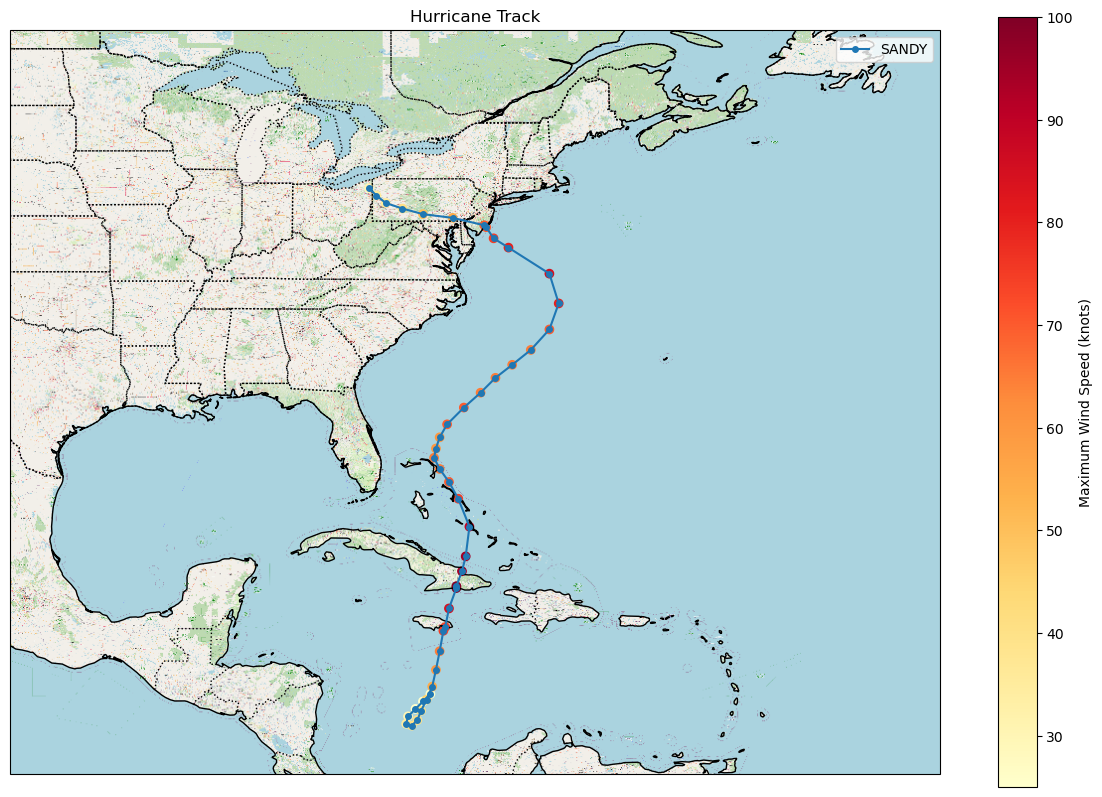

In [10]:
# Load and prepare hurricane data using the new class structure
hurdat2_file = '/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'

# Prepare sequences for LSTM training
hurricane_sequences, hurricane_ids = HistoricHurricane.get_training_sequences(
    hurdat2_file, min_wind_speed=50, min_sequence_length=10
)

# Example: View a single hurricane track
sample_id = 'AL182012'
historic_hurr = HistoricHurricane.from_hurdat2(hurdat2_file, sample_id)
historic_hurr.plot()

# # Print sample sequence data
# print(f"Sample sequence shape: {hurricane_sequences[10].shape}")
# print("Sample sequence data (first 3 points):")
# print(hurricane_sequences[10][:3])

## LSTM-VAE Model Implementation

The LSTM-VAE model is implemented as a separate class, and is used by `SyntheticHurricane` for generation.

In [11]:
@register_keras_serializable(package="Custom", name="sampling")
def _sampling(args):
    """Reparameterization trick for sampling from latent space"""
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class VAELossLayer(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl_loss = -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1)
        self.add_loss(tf.reduce_mean(kl_loss))
        return z_mean  # Return z_mean as a placeholder

## Training and Using the LSTM-VAE

Instantiate the model, train it, and generate synthetic hurricanes using the new class structure.

In [12]:
# --- Parameters ---
INPUT_DIM = 17
LATENT_DIM = 32
LSTM_UNITS = 64
EPOCHS = 50
BATCH_SIZE = 32

if not hurricane_sequences:
    print("Error: hurricane_sequences is not defined or empty. Please run the data preparation cells first.")
    FIXED_SEQUENCE_LENGTH = 50
else:
    FIXED_SEQUENCE_LENGTH = max(len(seq) for seq in hurricane_sequences)
    FIXED_SEQUENCE_LENGTH = min(FIXED_SEQUENCE_LENGTH, 75)
    print(f"Using fixed sequence length: {FIXED_SEQUENCE_LENGTH}")

# --- Initialize Model ---
lstm_vae = HurricaneLSTMVAE(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    sequence_length=FIXED_SEQUENCE_LENGTH,
    lstm_units=LSTM_UNITS
)

if 'hurricane_sequences' in locals() and hurricane_sequences:
    print(f"\nTraining LSTM-VAE with {len(hurricane_sequences)} sequences...")
    history = lstm_vae.train(
        hurricane_sequences,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2
    )

    if history:
        plt.figure(figsize=(12, 6))
        plt.plot(history.history['loss'], label='Training Loss (Reconstruction + KL)')
        plt.plot(history.history['val_loss'], label='Validation Loss (Reconstruction + KL)')
        if 'kl_loss' in history.history:
             plt.plot(history.history['kl_loss'], label='Training KL Loss (metric)')
        if 'val_kl_loss' in history.history:
             plt.plot(history.history['val_kl_loss'], label='Validation KL Loss (metric)')
        plt.title('LSTM-VAE Model Training History')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

    MODEL_SAVE_PATH = 'hurricane_lstm_vae_model_v2'
    lstm_vae.save_model(MODEL_SAVE_PATH)
    print(f"\nModel saved to prefix: {MODEL_SAVE_PATH}")

    loaded_lstm_vae = HurricaneLSTMVAE(
        input_dim=INPUT_DIM,
        latent_dim=LATENT_DIM,
        sequence_length=FIXED_SEQUENCE_LENGTH,
        lstm_units=LSTM_UNITS
    )
    loaded_lstm_vae.load_model(MODEL_SAVE_PATH)
    print("LSTM-VAE Model loaded successfully from prefix.")

    # --- Generate Synthetic Hurricane Tracks using the new class ---
    print("\nGenerating a random synthetic hurricane track...")
    # Fix: Use the SyntheticHurricane instance, not the classmethod with loaded_lstm_vae
    synthetic_hurr = SyntheticHurricane(
        input_dim=INPUT_DIM,
        latent_dim=LATENT_DIM,
        sequence_length=FIXED_SEQUENCE_LENGTH,
        lstm_units=LSTM_UNITS
    )
    synthetic_hurr.load(MODEL_SAVE_PATH)
    track_df = synthetic_hurr.generate(num_points=FIXED_SEQUENCE_LENGTH, randomness=0.8)
    print("Generated Random Synthetic Track (first 5 points):")
    print(track_df.head())
    synthetic_hurr.plot(title="Randomly Generated LSTM-VAE Hurricane Track")

    if hurricane_sequences:
        seed_index = 0
        if seed_index < len(hurricane_sequences):
            seed_track_raw_features = hurricane_sequences[seed_index]
            original_seed_id = hurricane_ids[seed_index]
            print(f"\nGenerating a synthetic hurricane track seeded from: {original_seed_id}...")
            seeded_track_df = synthetic_hurr.generate(
                seed_features=seed_track_raw_features,
                num_points=FIXED_SEQUENCE_LENGTH,
                randomness=0.3
            )
            print("Generated Seeded Synthetic Track (first 5 points):")
            print(seeded_track_df.head())
            synthetic_hurr.plot(title=f"LSTM-VAE Generated Track (Seeded by {original_seed_id})")

            # For comparison, plot the original seed
            original_seed_df = pd.DataFrame(
                seed_track_raw_features,
                columns=[
                    'latitude', 'longitude', 'max_wind', 'min_pressure',
                    'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius',
                    'ne_50kt_radius', 'se_50kt_radius', 'sw_50kt_radius', 'nw_50kt_radius',
                    'ne_64kt_radius', 'se_64kt_radius', 'sw_64kt_radius', 'nw_64kt_radius',
                    'radius_max_wind'
                ]
            )
            original_seed_df['storm_name'] = f"Original_{original_seed_id}"
            original_seed_df['datetime'] = [datetime.now() + timedelta(hours=i*6) for i in range(len(original_seed_df))]
            fig_comp = plt.figure(figsize=(14, 10))
            ax_comp = plt.axes(projection=ccrs.PlateCarree())
            ax_comp.add_feature(cfeature.COASTLINE, zorder=3)
            ax_comp.add_feature(cfeature.BORDERS, linestyle=':', zorder=3)
            all_lons = pd.concat([original_seed_df['longitude'], seeded_track_df['longitude']])
            all_lats = pd.concat([original_seed_df['latitude'], seeded_track_df['latitude']])
            ax_comp.set_extent([all_lons.min() - 5, all_lons.max() + 5, 
                                all_lats.min() - 5, all_lats.max() + 5], crs=ccrs.PlateCarree())
            try:
                osm_tiles_comp = cimgt.OSM()
                ax_comp.add_image(osm_tiles_comp, 6, zorder=1)
            except Exception:
                pass
            ax_comp.plot(original_seed_df['longitude'], original_seed_df['latitude'],
                         '-o', color='blue', markersize=4, transform=ccrs.Geodetic(), 
                         label=f"Original Seed: {original_seed_id}", zorder=4)
            ax_comp.plot(seeded_track_df['longitude'], seeded_track_df['latitude'],
                         '-o', color='green', markersize=4, transform=ccrs.Geodetic(), 
                         label=f"Synthetic (Seeded): {synthetic_hurr.storm_name}", zorder=5)
            ax_comp.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, zorder=2)
            plt.title(f"Comparison: Original Seed ({original_seed_id}) vs. LSTM-VAE Generated Track")
            plt.legend()
            plt.show()
        else:
            print(f"Seed index {seed_index} is out of bounds for hurricane_sequences (length {len(hurricane_sequences)}). Skipping seeded generation.")
    else:
        print("No hurricane_sequences available to use as a seed. Skipping seeded generation.")
else:
    print("Skipping LSTM-VAE training and generation as 'hurricane_sequences' is not available or empty.")

Using fixed sequence length: 75


NameError: name 'HurricaneLSTMVAE' is not defined

In [ ]:
# Create and use a SyntheticHurricane instance
synthetic_hurr = SyntheticHurricane(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    sequence_length=FIXED_SEQUENCE_LENGTH,
    lstm_units=LSTM_UNITS
)
history = synthetic_hurr.train(hurricane_sequences, epochs=EPOCHS, batch_size=BATCH_SIZE)
synthetic_hurr.save(MODEL_SAVE_PATH)
synthetic_hurr.load(MODEL_SAVE_PATH)
track_df = synthetic_hurr.generate(num_points=FIXED_SEQUENCE_LENGTH, randomness=0.8)
synthetic_hurr.plot()